In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import os

In [37]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(os.path.abspath('..'))
from scripts.data_loader import MacroDataLoader

loader = MacroDataLoader('../data/master_data1.csv')
loader.load()
df = loader.df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
print(df.columns.tolist())
print('==='*20)
print(df.shape)
print('==='*20)
print(df.describe())
print('==='*20)
print(df.info())
print('==='*20)
print(df.head(3))
print('==='*20)
print(df.dtypes)


['iip', 'm3', 'repo_rate', 'tbill_91d', 'gsec_10yr', 'inr_usd', 'cpi_inflation', 'fed_funds_rate', 'crude_oil_brent', 'term_spread']
(172, 10)
              iip          m3   repo_rate   tbill_91d   gsec_10yr     inr_usd  \
count  172.000000  172.000000  172.000000  172.000000  172.000000  172.000000   
mean     2.828613   10.371257    6.227616    6.422401    7.272362   71.177015   
std      7.582591    1.755963    1.256646    1.702743    0.754694   10.182927   
min    -57.300000    5.559142    4.000000    2.929200    5.783300   48.940800   
25%      1.000000    9.405226    5.500000    5.470675    6.706850   63.918375   
50%      3.525252   10.366205    6.500000    6.521900    7.203000   70.491300   
75%      5.122086   11.331408    7.250000    7.341700    7.803725   81.531675   
max     27.600000   15.823262    8.500000   12.021800    8.889100   92.460000   

       cpi_inflation  fed_funds_rate  crude_oil_brent  term_spread  
count     172.000000      172.000000       172.000000   17

In [25]:
#Plotting all the variables
variables = df.columns.to_list()
for var in variables:
    fig = px.line(df, x=df.index, y=var , title='')
    fig.show()


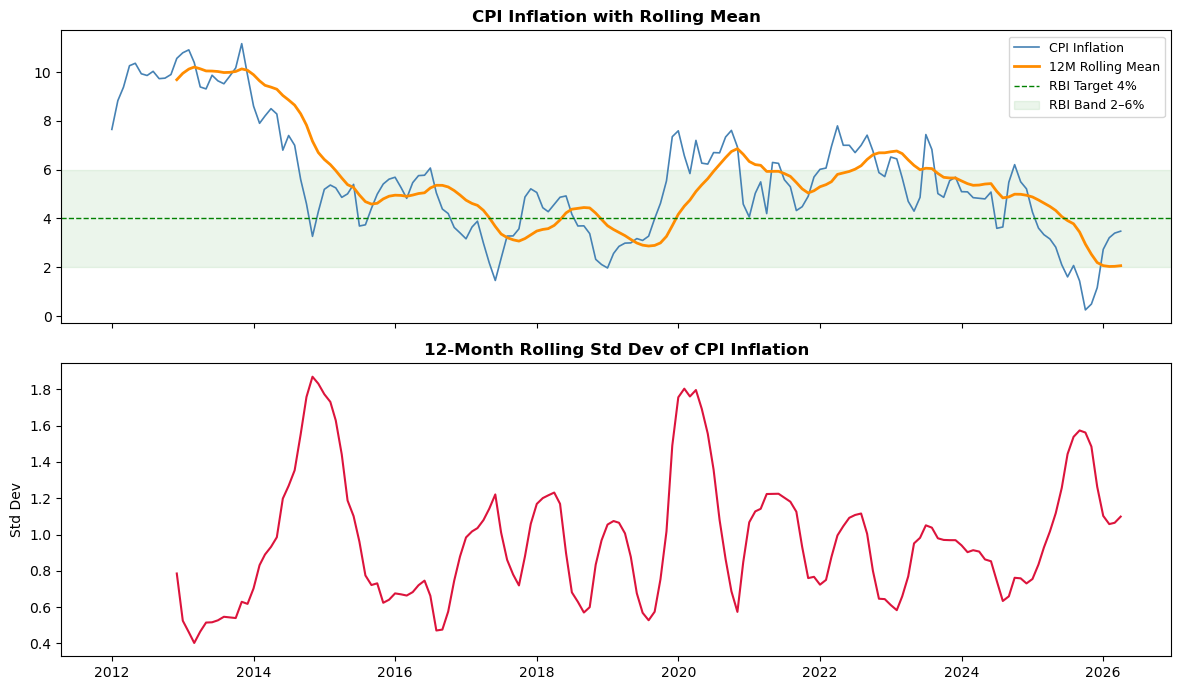

In [26]:
#plotting cpi rolling mean and rolling std

cpi = df['cpi_inflation']

rolling_mean = cpi.rolling(window=12).mean()
rolling_std  = cpi.rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(cpi.index, cpi, label='CPI Inflation', color='steelblue', linewidth=1.2)
axes[0].plot(rolling_mean.index, rolling_mean, label='12M Rolling Mean', 
             color='darkorange', linewidth=2)
axes[0].axhline(y=4, color='green', linestyle='--', linewidth=1, label='RBI Target 4%')
axes[0].axhspan(2, 6, alpha=0.08, color='green', label='RBI Band 2–6%')
axes[0].set_title('CPI Inflation with Rolling Mean', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(rolling_std.index, rolling_std, color='crimson', linewidth=1.5)
axes[1].set_title('12-Month Rolling Std Dev of CPI Inflation', fontweight='bold')
axes[1].set_ylabel('Std Dev')

plt.tight_layout()
plt.show()

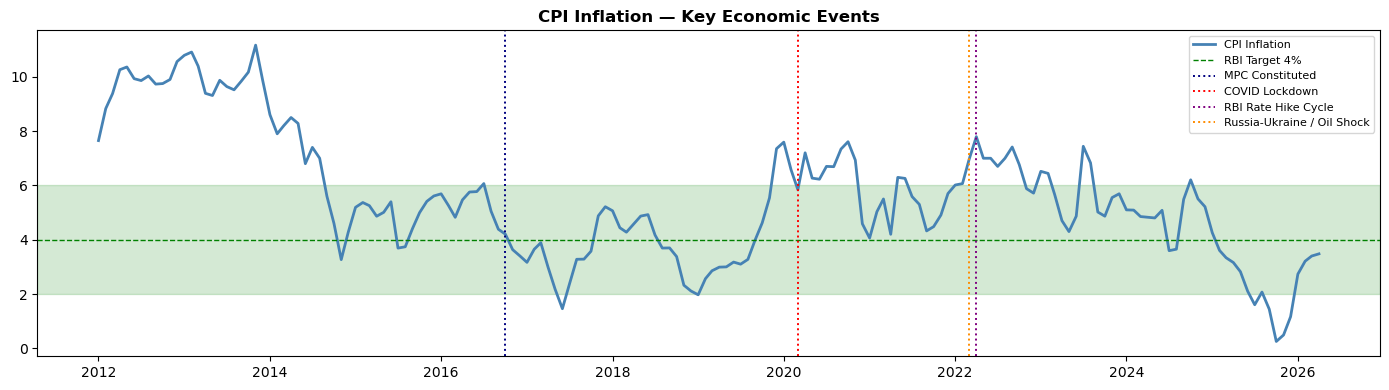

In [27]:
events = {'2016-10-01': 'MPC Constituted',
          '2020-03-01': 'COVID Lockdown',
          '2022-04-01': 'RBI Rate Hike Cycle',
          '2022-03-01': 'Russia-Ukraine / Oil Shock'}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cpi.index, cpi, color='steelblue', linewidth=2, label='CPI Inflation')
ax.axhline(y=4, color='green', linestyle='--', linewidth=1, alpha=1, label='RBI Target 4%')
ax.axhspan(2, 6, alpha=0.17, color='green')

colors = ['navy', 'red', 'purple', 'darkorange']
for (date_str, label), color in zip(events.items(), colors):
    ax.axvline(pd.Timestamp(date_str), color=color, linestyle=':', 
               linewidth=1.4, label=label)

ax.set_title('CPI Inflation — Key Economic Events', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

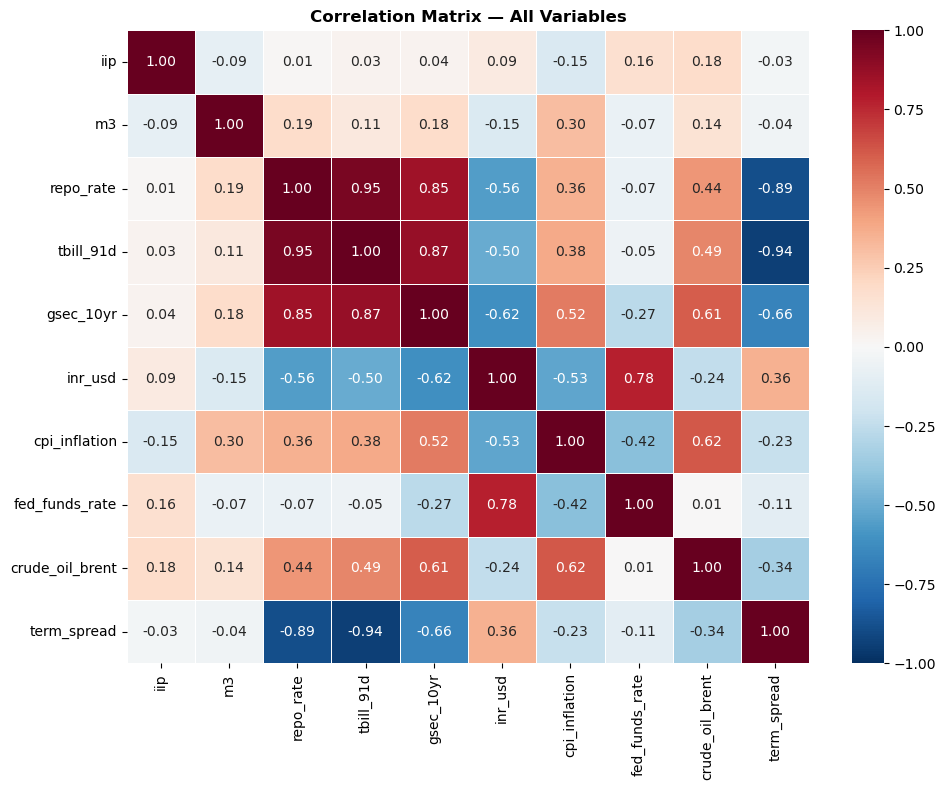

In [28]:
#correleaion matrix
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()

sns.heatmap( corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)

ax.set_title('Correlation Matrix — All Variables', fontweight='bold')
plt.tight_layout()
plt.show()

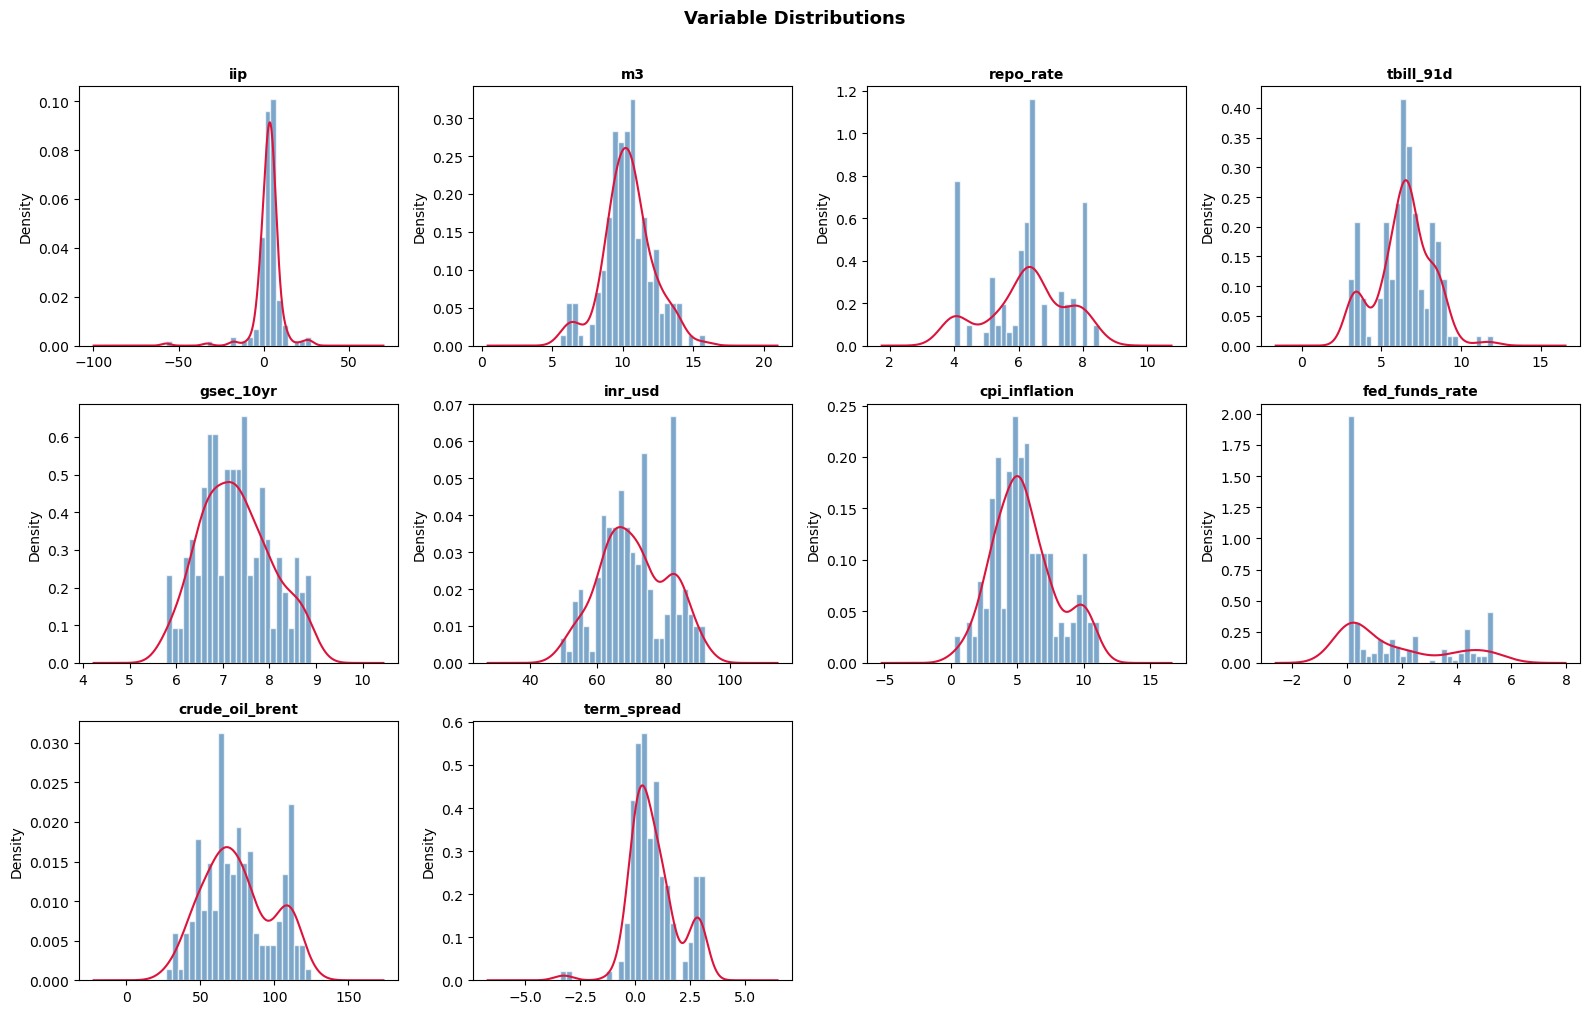

In [29]:
#Distribution chart

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(df.columns):
    axes[i].hist(df[var].dropna(), bins=25, color='steelblue', 
                 edgecolor='white', alpha=0.7, density=True)
    df[var].dropna().plot.kde(ax=axes[i], color='crimson', linewidth=1.5)
    axes[i].set_title(var, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')

# Hide the last empty subplot if columns < 12
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variable Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

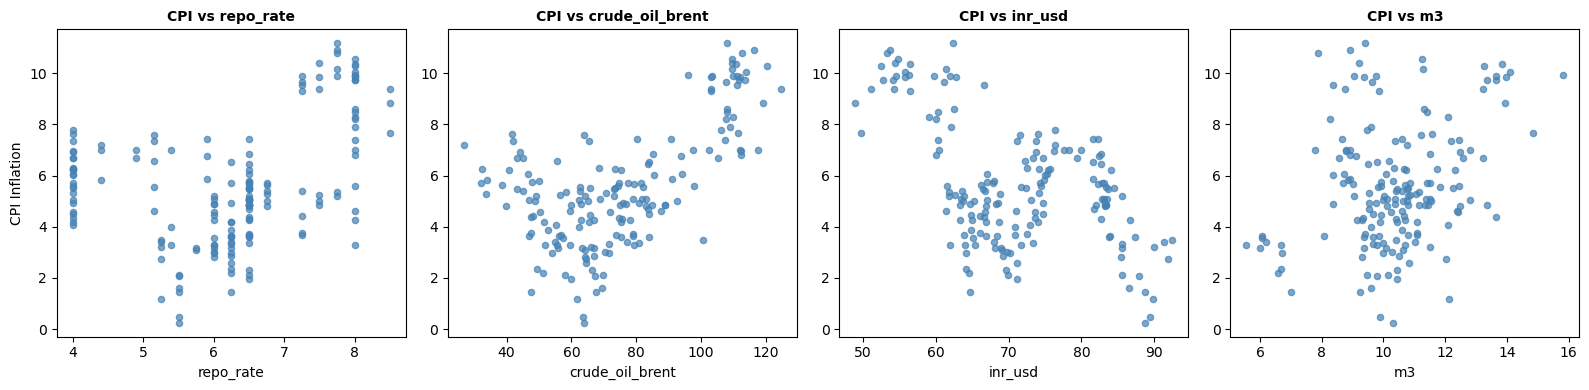

In [30]:
#scatter plot
drivers = ['repo_rate', 'crude_oil_brent', 'inr_usd', 'm3']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, driver in enumerate(drivers):
    axes[i].scatter(df[driver], df['cpi_inflation'], 
                    alpha=0.7, color='steelblue', s=20)
    axes[i].set_xlabel(driver)
    axes[i].set_ylabel('CPI Inflation' if i == 0 else '')
    axes[i].set_title(f'CPI vs {driver}', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

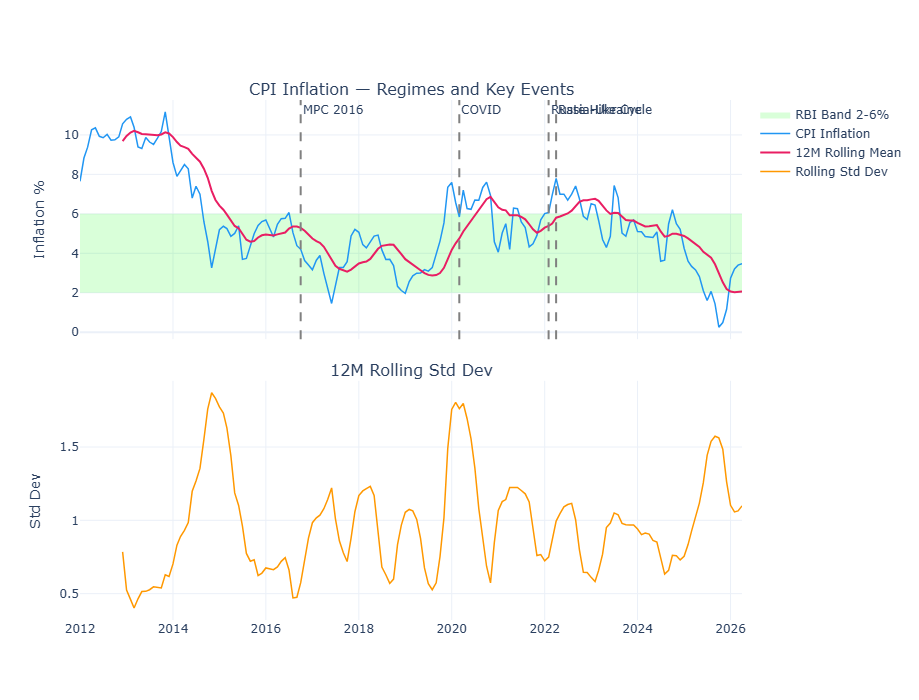

In [31]:
#plotting CPI 12 month rolling window mean and std, along with various regimes

rolling_mean = df['cpi_inflation'].rolling(12).mean()
rolling_std = df['cpi_inflation'].rolling(12).std()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.08,
                    subplot_titles=['CPI Inflation — Regimes and Key Events',
                                    '12M Rolling Std Dev'])

# RBI band
#fig.add_hrect(y0=2, y1=6, fillcolor='lightgreen', opacity=0.7,line_width=1.2, annotation_text='RBI Band 2-6%', row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index.tolist() + df.index.tolist()[::-1],
    y=[6]*len(df) + [2]*len(df),
    fill='toself',
    fillcolor='rgba(0, 255, 0, 0.15)',
    line=dict(width=0),
    name='RBI Band 2-6%',
    showlegend=True
), row=1, col=1)   

# CPI actual
fig.add_trace(go.Scatter(x=df.index, y=df['cpi_inflation'],
              name='CPI Inflation', line=dict(color='#2196F3', width=1.5)),
              row=1, col=1)

# Rolling mean
fig.add_trace(go.Scatter(x=df.index, y=rolling_mean,
              name='12M Rolling Mean', line=dict(color='#E91E63', width=2)),
              row=1, col=1)

# Event lines — both panels
events = {
    '2016-10-01': 'MPC 2016',
    '2020-03-01': 'COVID',
    '2022-02-01': 'Russia-Ukraine',
    '2022-04-01': 'Rate Hike Cycle'
}

for date, label in events.items():
    fig.add_vline(x=pd.Timestamp(date).timestamp() * 1000,
                  line_dash='dash',
                  line_color='gray',
                  annotation_text=label)

# Rolling std
fig.add_trace(go.Scatter(x=df.index, y=rolling_std,
              name='Rolling Std Dev', line=dict(color='#FF9800', width=1.5)),
              row=2, col=1)

fig.update_layout(
    template='plotly_white',
    height=700,
    yaxis_title='Inflation %',
    yaxis2_title='Std Dev'
)

fig.show()

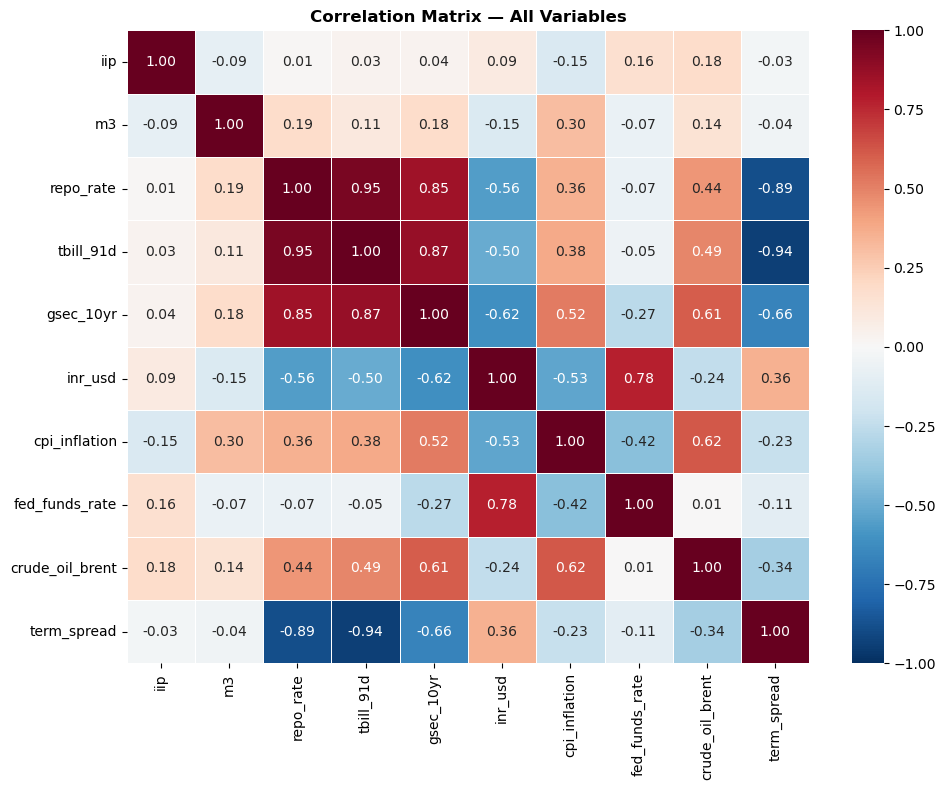

In [32]:
#correlation matrix plot for all variable
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()

sns.heatmap( corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)

ax.set_title('Correlation Matrix — All Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
#plotting cross correlation function to see lagged correlation of CPi with other variable

from statsmodels.tsa.stattools import ccf

variables_ccf = ['crude_oil_brent', 'fed_funds_rate', 'inr_usd', 'repo_rate']
lags = 12
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

fig = make_subplots(rows=2, cols=2, subplot_titles=variables_ccf, vertical_spacing=0.15, horizontal_spacing=0.1)

for i, (var, color) in enumerate(zip(variables_ccf, colors)):
    row = i // 2 + 1
    col = i % 2 + 1
    
    ccf_values = ccf(df['cpi_inflation'].dropna(), 
                     df[var].dropna(), nlags=lags)
    
    fig.add_trace(go.Bar(
        x=list(range(0, lags + 1)),
        y=ccf_values,
        name=var,
        marker_color=color
    ), row=row, col=col)
    
    # Zero reference line
    fig.add_hline(y=0, line_color='black', 
                  line_width=0.8, row=row, col=col)

fig.update_layout(
    title='Cross Correlation — CPI Inflation vs Key Predictors',
    template='plotly_white',
    height=600,
    showlegend=False
)

fig.update_xaxes(title_text='Lag (Months)')
fig.update_yaxes(title_text='Correlation')

fig.show()

In [34]:
variables_rc = ['crude_oil_brent', 'm3']
colors = ['#2196F3', '#E91E63']
window = 24

fig = go.Figure()

for var, color in zip(variables_rc, colors):
    rolling_corr = df['cpi_inflation'].rolling(window).corr(df[var])
    fig.add_trace(go.Scatter(
        x=df.index, y=rolling_corr,
        name=var, line=dict(color=color, width=2)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)

fig.update_layout(
    title='24 Month Rolling Correlation — CPI vs Crude Oil and M3',
    template='plotly_white',
    height=450,
    yaxis_title='Rolling Correlation'
)

fig.show()

# EDA Summary — Key Findings

## Data Overview
- 169 monthly observations, January 2012 to January 2026
- 10 variables — CPI inflation, repo rate, M3, IIP, T-bill, G-Sec, 
  INR/USD, term spread, Fed funds rate, crude oil
- Zero missing values, all variables in percentage or level form

## CPI Inflation — Regime Structure
- Pre-2016: Inflation was unanchored, ranging 8-12%, high volatility, 
  no gravitational pull toward any target
- Post-2016 FIT: Inflation compressed toward 4% RBI target, 
  volatility halved, non-crisis periods consistently anchored
- Crisis events — COVID 2020 and Russia-Ukraine 2022 — temporarily 
  breached the 2-6% band but inflation returned toward target each time
- This mean reversion behavior in non-crisis periods is the strongest 
  visual evidence of the FIT regime change

## Interest Rate Structure
- Repo rate, T-bill, and G-Sec move together with correlations 
  of 0.95 and 0.85 respectively
- T-bill reacts faster and more sharply to RBI policy — 
  short end instrument with 91 day horizon
- G-Sec moves slower, incorporates inflation expectations 
  and term premium on top of policy rate
- Term spread was negative pre-2016 during monetary stress periods,
  consistently positive post-2016 reflecting anchored expectations
- Near zero term spread in 2022-23 reflects aggressive RBI tightening 
  where short end caught up to long end rapidly

## Exchange Rate and External Sector
- INR/USD shows persistent depreciation trend — non-stationary series,
  requires transformation in notebook 02
- INR/USD correlation with Fed funds rate is 0.78 — highest in dataset
- Mechanism: Fed hikes → FPI outflows from India → rupee depreciation
- This confirms P1 finding that exchange rate is driven by external 
  factors, not domestic monetary policy

## Crude Oil and CPI
- Strongest contemporaneous relationship in dataset — 0.62 correlation
- Scatter plot confirms clear upward diagonal — bottom left to top right
- Transmission is fast — petrol prices, transport costs, input costs 
  adjust within 1 to 2 months
- CCF confirmed lag 0 and lag 1 are nearly equal strength

## M3 and CPI
- Near zero contemporaneous correlation — shapeless scatter plot
- Consistent with P1 finding that M3 operates through level 
  relationships over 12 to 24 months, not month to month flows
- Lag features of M3 will capture this relationship in notebook 02

## Distribution Insights
- Repo rate shows multiple peaks reflecting discrete RBI policy 
  decisions — rates held flat for months then shifted
- Crude oil shows bimodal distribution — 2020 crash cluster 
  and normal 60-100 dollar trading range cluster
- CPI shows small right tail peak — post-2016 anchored main cluster 
  with 2022 supply shock observations pulling right
- INR/USD shows two humps — pre and post depreciation regimes
- IIP shows extreme left tail outlier from COVID crash — 
  single observation that will disproportionately influence the model

## Scatter Plot Findings
- Repo rate vs CPI — vertical clusters at discrete rate levels, 
  no directional relationship — confirms lag structure dominates
- Crude oil vs CPI — clearest linear relationship in dataset
- INR/USD vs CPI — S shaped non-linear pattern reflecting 
  regime dependent relationship, two separate clouds merged
- M3 vs CPI — completely random cloud, contemporaneous 
  relationship absent as expected

## Rolling Correlation — Most Important EDA Finding
- 24 month rolling correlation between CPI and crude oil versus 
  CPI and M3 reveals a striking pattern
- The two lines move in near perfect opposite directions throughout 
  the sample — a consistent criss-cross pattern
- When crude oil correlation with CPI is high, M3 correlation is low 
  and vice versa
- Economic interpretation: Indian inflation has two competing drivers 
  that take turns dominating
- During supply shock periods — 2014 oil crash, 2022 Russia-Ukraine — 
  external commodity prices overwhelm domestic monetary conditions, 
  crude oil drives CPI and M3 signal weakens
- During calm periods with stable global commodities — 2017 to 2019, 
  2023 to 2024 — domestic monetary transmission reasserts itself, 
  M3 drives CPI and crude oil signal weakens
- This time varying dominance pattern means the relationship between 
  inflation and its drivers is not stable across the sample
- Direct implication: ARIMA cannot capture this switching behavior. 
  XGBoost with time varying lag features and SHAP interpretation 
  can — and SHAP in notebook 05 should confirm this exact pattern
- This finding also extends P1 — P1 found M3 explains 55.6% of 
  inflation variance on average. P2 now shows that average conceals 
  a time varying relationship where M3 dominance itself fluctuates 
  with global commodity cycles

## Why XGBoost Over ARIMA — EDA Verdict
- Multiple non-linear relationships visible in scatter plots
- Regime dependent behavior confirmed visually and statistically
- Time varying driver importance confirmed by rolling correlation
- Lagged transmission channels confirmed by CCF
- ARIMA assumes one linear stable process — all four findings 
  above violate that assumption simultaneously
- XGBoost handles non-linearity, multiple variables, regime 
  dependence, and lag structures in one framework